# Лабораторна робота №3 
## Кластеризація

### Мета:
Ознайомитися з методами кластеризації (clustering) на прикладі реального набору музичних даних Spotify Tracks Dataset. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя (elbow), виконувати кластеризацію методом K-Means, знижувати розмірність простору ознак за допомогою PCA для візуалізації та аналізувати характеристики утворених кластерів.

#### 1. Завантаження та підготовка даних
1. Завантажити набір даних.
2. Вивести перші кілька рядків і статистики колонок.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('SpotifyFeatures.csv')
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [2]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  str    
 1   artist_name       232725 non-null  str    
 2   track_name        232724 non-null  str    
 3   track_id          232725 non-null  str    
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  str    
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  str    
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    232725 non-nu

3. Виконати стандартизацію числових ознак.


In [4]:
numeric_df = df.select_dtypes(include=np.number)
numeric_df.head()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
0,0,0.611,0.389,99373,0.910,0.000,0.3460,-1.828,0.0525,166.969,0.814
1,1,0.246,0.590,137373,0.737,0.000,0.1510,-5.559,0.0868,174.003,0.816
2,3,0.952,0.663,170267,0.131,0.000,0.1030,-13.879,0.0362,99.488,0.368
3,0,0.703,0.240,152427,0.326,0.000,0.0985,-12.178,0.0395,171.758,0.227
4,4,0.950,0.331,82625,0.225,0.123,0.2020,-21.150,0.0456,140.576,0.390


4. Для зменшення кількості точок у візуалізації залишити лише треки з popularity ≥ 85.
5. Вивести розмірність таблиці після фільтрації.

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)
popular_df = df[df['popularity'] >= 85]
popular_df.shape


(417, 18)

In [6]:
popular_df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
9028,Dance,Halsey,Without Me,5p7ujcrUXASCNwRaWNHR1C,97,0.2970,0.752,201661,0.488,0.000009,F#,0.0936,-7.050,Major,0.0705,136.041,4/4,0.533
9029,Dance,Ariana Grande,needy,1TEL6MlSSVLSdhOSddidlJ,92,0.7800,0.647,171573,0.309,0.000007,G,0.2020,-7.948,Minor,0.0366,87.045,4/4,0.195
9030,Dance,Ariana Grande,NASA,4uTvPEr01pjTbZgl7jcKBD,91,0.4510,0.747,182000,0.458,0.000000,F#,0.2520,-6.891,Major,0.3030,75.029,4/4,0.470


#### 2. Підбір оптимальної кількості кластерів (k) — метод ліктя
1. Ініціалізувати модель KMeans із різною кількістю кластерів (наприклад k = 2…15).
2. Для кожного k обчислити інерцію (суму квадратів відстаней до центрів кластерів).


In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_range = range(2, 16)
wcss_values = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss_values.append(kmeans.inertia_)

Побудувати графік залежності інерції від k.

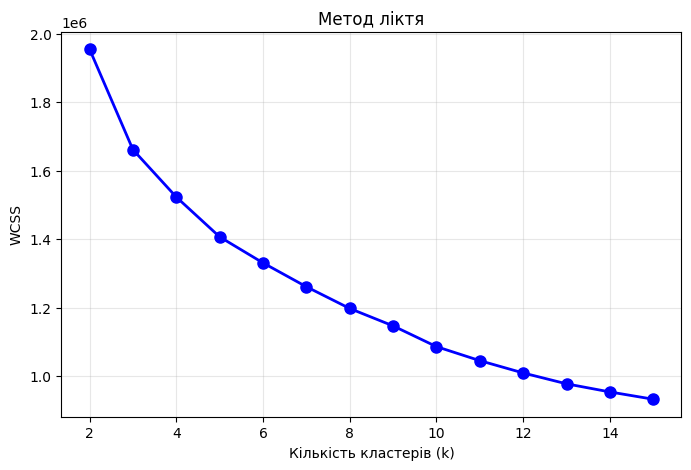

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('WCSS')
plt.title('Метод ліктя')
plt.grid(True, alpha=0.3)
plt.show()

4. Визначити оптимальне k.


In [9]:
K = 5

#### 3. Побудова кластеризації
1. Виконати кластеризацію з обраним значенням k.


In [10]:
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

2. Додати отримані мітки кластерів до DataFrame як нову колонку cluster.

In [16]:
df.drop(columns='cluster', inplace=True)
df.insert(0, 'cluster', clusters)
df.head()

,cluster,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,1,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,4,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,4,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


3. 

In [17]:
df['cluster'].value_counts().sort_index()

cluster
0    29443
1    60841
2    87225
3    10108
4    45108
Name: count, dtype: int64

#### 4. Візуалізація кластерів у просторі головних компонент
1. Виконати PCA до двох/трьох компонент для візуалізації.

In [18]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
pca_2d_data = pca_2d.fit_transform(scaled_data)

df['pca1'] = pca_2d_data[:, 0]
df['pca2'] = pca_2d_data[:, 1]

pca_3d = PCA(n_components=3)
pca_3d_data = pca_3d.fit_transform(scaled_data)

df['pca3'] = pca_3d_data[:, 2]
popular_df = df[df['popularity'] >= 85]
popular_df['cluster'].value_counts().sort_index()

cluster
1     45
2    358
4     14
Name: count, dtype: int64

2. Побудувати 2D/3D-графік з кольором точок за значенням cluster. Для покращення читабельності візуалізувати лише треки з popularity ≥ 85.

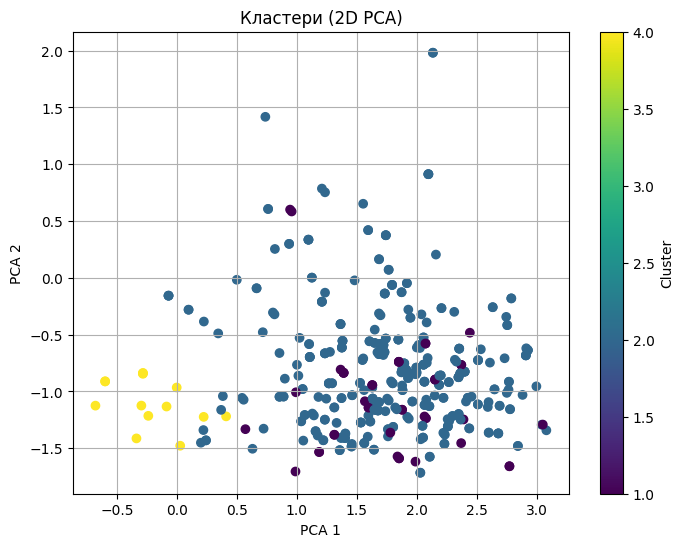

In [19]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    popular_df['pca1'],
    popular_df['pca2'],
    c=popular_df['cluster'],
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Кластери (2D PCA)')
plt.colorbar(scatter, label='Cluster')

plt.grid()
plt.show()

In [23]:
import plotly.express as px

popular_df_plot = popular_df.copy()

popular_df_plot['cluster'] = popular_df_plot['cluster'].astype(str)

fig = px.scatter_3d(
    popular_df_plot,
    x='pca1',
    y='pca2',
    z='pca3',
    color='cluster',
    title="Кластери (3D PCA)",
    height=700
)

fig.update_traces(marker=dict(size=4))

fig.show()

#### 5. Аналіз кластерів
1. Для кожного кластера обчислити статистики основних ознак.


In [21]:
features_for_analysis = [
    'danceability',
    'energy',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
]
cluster_means = df.groupby('cluster')[features_for_analysis].mean()
cluster_means = cluster_means.round(3)
cluster_means

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence
cluster,,,,,,,
0,0.286,0.160,0.047,0.856,0.680,0.154,0.148
1,0.496,0.771,0.093,0.104,0.100,0.250,0.451
2,0.696,0.676,0.106,0.174,0.050,0.172,0.604
3,0.562,0.662,0.877,0.793,0.001,0.730,0.414
4,0.531,0.347,0.066,0.689,0.089,0.175,0.381


2. Побудувати таблицю середніх значень основних ознак або графік (heatmap).


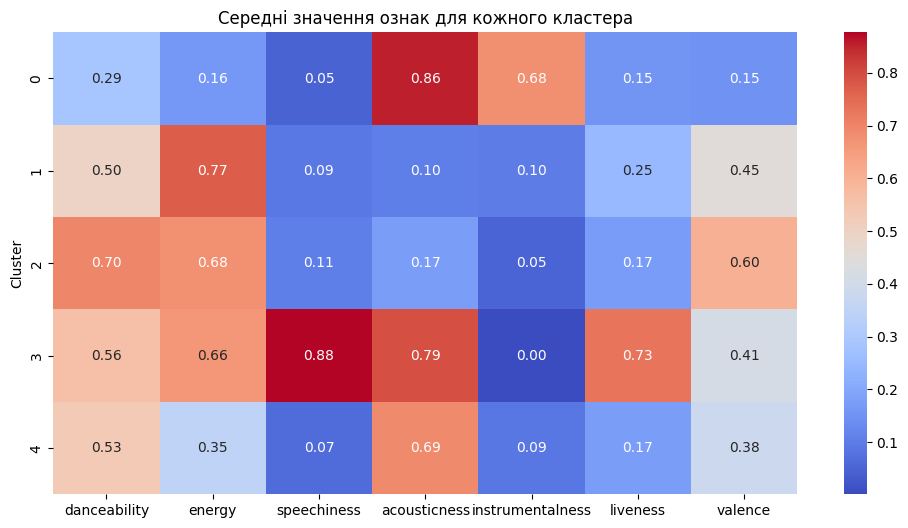

In [22]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Середні значення ознак для кожного кластера')
plt.ylabel('Cluster')
plt.show()

3. Інтерпретувати кластери

1. danceability (танцювальність) - показує, наскільки трек підходить для танцю
2. energy (енергійність) - характеризує інтенсивність і енергійність треку
3. speechiness (розмовність) - показує, наскільки багато мовлення у треку
4. acousticness (акустичність) - показує наскільки трек акустичний
5. instrumentalness (інструментальність) - високе значення без вокалу, низьке є вокал
6. liveness (живість виконання) - чи запис зроблено наживо
7. valence (емоційність) - високе значення веселі треки, низьке сумні

**Кластер 0**

Високі: acousticness = 0.86, instrumentalness = 0.68

Низькі: energy = 0.16, danceability = 0.29, valence = 0.15

Спокійні акустичні інструментальні треки (ambient, lo-fi, класика без вокалу). Повільні, не для танців, більш “фонова” музика.

**Кластер 1**

Високі: energy = 0.77, valence = 0.45

Низькі: acousticness = 0.10, instrumentalness = 0.10

Енергійна сучасна музика (поп, електроніка) з вокалом, мало акустики

**Кластер 2**

Високі: danceability = 0.70,  energy = 0.68, valence = 0.60

Низькі: instrumentalness = 0.05, acousticness = 0.17

Танцювальні, позитивні треки (dance-pop, EDM, клубна музика). Яскраві, ритмічні треки.

**Кластер 3**

Високі: speechiness = 0.88, acousticness = 0.79, liveness = 0.73

Низькі: instrumentalness = 0.00

Реп / spoken word / live-виступи. Багато мовлення, майже без інструменталу.

**Кластер 4**

Високі: acousticness = 0.69

Середні: danceability = 0.53, valence = 0.38

Низькі: energy = 0.35, instrumentalness = 0.09

М’які вокальні акустичні треки (інді, поп-балади).

Не всі кластери представлені серед популярних треків: спокійні інструментальні (кластер 0) та треки з високою часткою мовлення (кластер 3) не потрапляють у топ, тоді як найбільш популярними є енергійні (кластер 1) та танцювальні композиції (кластер 2).

### Висновок
У ході роботи було виконано кластеризацію музичних треків за допомогою методу K-Means, попередньо стандартизувавши дані та визначивши оптимальну кількість кластерів методом ліктя. За допомогою PCA результати були візуалізовані у 2D та 3D просторі, що дозволило наочно побачити структуру кластерів. Аналіз середніх значень ознак показав, що кластери відповідають різним типам музики (енергійні, танцювальні, акустичні, інструментальні тощо), а також виявив, що не всі типи треків однаково представлені серед популярних.